Author: Esteban Alfaro 

Email: alfaro8511@gmail.com

Date: june 2023

Website: https://estebanalfaro328753397.wordpress.com/

Original images from Google Earth

<span style="background-color: yellow;">Crossplots de propiedades</span>

Al realizar crossplots (gráficos de dispersión) entre las bandas de una imagen, es posible extraer información sobre la relación y la correlación entre los componentes de la imagen. Los crossplots permiten visualizar la distribución conjunta de los valores de dos bandas y proporcionan una idea de cómo se relacionan entre sí. Aquí hay algunas formas en las que se puede extraer información a través de crossplots:

    Identificar correlaciones lineales: Al graficar una banda en el eje x y otra banda en el eje y, es posible identificar patrones lineales en el gráfico de dispersión. Si los puntos en el gráfico siguen una tendencia lineal, esto indica una correlación lineal entre las dos bandas. La pendiente y la dirección de la línea de regresión pueden proporcionar información sobre la relación entre los componentes de la imagen.

    Distinguir clases o categorías: Al realizar crossplots entre diferentes bandas, es posible distinguir diferentes clases o categorías de objetos en la imagen. Por ejemplo, en una imagen satelital, se puede realizar un crossplot entre las bandas que representan vegetación y suelo no vegetado. Esto puede ayudar a identificar regiones de vegetación, áreas urbanas y cuerpos de agua, según cómo se distribuyan los puntos en el gráfico.

    Detectar anomalías o características específicas: Al observar un crossplot, es posible identificar puntos atípicos o anomalías que se desvían de la tendencia general. Estas anomalías pueden indicar la presencia de características o elementos inusuales en la imagen. Por ejemplo, en una imagen térmica, se puede realizar un crossplot entre la banda térmica y la banda visible para detectar áreas con temperaturas inusuales o focos de calor.

    Evaluar la separabilidad de clases: Al realizar crossplots entre bandas de diferentes objetos o materiales en una imagen, se puede evaluar la separabilidad de las clases. Si las clases se superponen significativamente en el gráfico de dispersión, puede indicar que es difícil distinguir esas clases utilizando solo esas dos bandas. Por otro lado, si las clases están bien separadas, indica una mayor capacidad para distinguir entre ellas.

Estas son solo algunas formas en las que los crossplots entre bandas pueden proporcionar información útil sobre los componentes de una imagen. La interpretación de los crossplots depende del contexto específico y del tipo de datos que estés analizando.

In [32]:
#agrupar clases espectrales con clustering k-means (machine learning no supervisado)

In [33]:
#instalar librería scikit
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [34]:
#importar librerias
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

In [35]:
################Crossplot del espectro visible en foto aerea Colombia
#leer imagen de sensor remoto

imagen=io.imread('imagenes_sensoresremotos/aerea2.tiff') #fuente: captura satélite Google Earth (RGBA)
#imagen=io.imread('imagenes_sensoresremotos/satelite_7.jpg') #fuente: captura satélite Google Earth (RGBA)

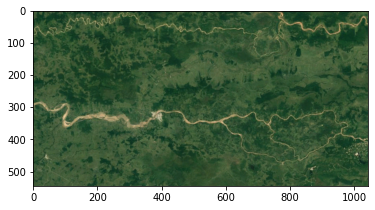

In [36]:
#visualizar imagen
plt.imshow(imagen)
plt.show()

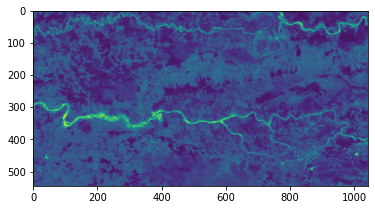

In [45]:
#fragmentar imagen por bandas
rojo=imagen[:,:,0]
verde=imagen[:,:,1]
azul=imagen[:,:,2]

#visualizar rojo
plt.imshow(rojo)
plt.show()

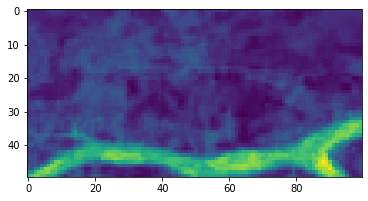

In [57]:
#recortar imagen
rojo1=rojo[300:350,500:600]
verde1=verde[300:350,500:600]
azul1=azul[300:350,500:600]

#visualizar rojo
plt.imshow(rojo1)
plt.show()

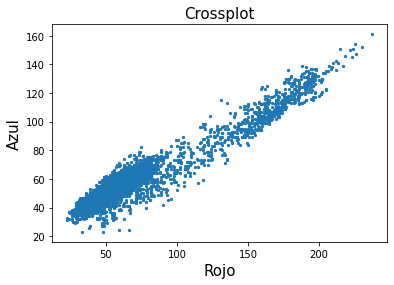

In [76]:
#hacer crossplot entre rojo y verde
plt.scatter(rojo1,azul1,s=5)
plt.xlabel('Rojo',size=15)
plt.ylabel('Azul',size=15)
plt.title('Crossplot',size=15)
plt.show()

In [69]:
#clustering k-means
#convertir el array en una forma unidimensional
rojo1=np.reshape(rojo1,-1)
verde1=np.reshape(verde1,-1)
azul1=np.reshape(azul1,-1)
datos=list(zip(rojo1,azul1)) #crear matriz de datos x,y
from sklearn.cluster import KMeans

In [81]:
gupi=3 #número de clusters
mamut=KMeans(gupi, random_state=0) #crear función kmeans
conejo = mamut.fit(datos)  #agrupar
clusters = conejo.labels_ #etiqueta grupos con números
colores =  ['red', 'green','blue']
centroides = conejo.cluster_centers_

/home/esteban/.local/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


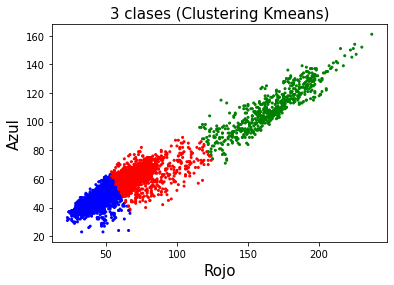

In [82]:
#grafica
plt.xlabel('Rojo',size=15)
plt.ylabel('Azul',size=15)
plt.title('3 clases (Clustering Kmeans)',size=15)
plt.scatter(rojo1,azul1,c=[colores[label] for label in clusters],s=4)
plt.show()

In [41]:
# calcula las coordenadas de los centroides finales
centroids = conejo.cluster_centers_